### Demoblatt - LuS
--- 



# `Feature Scaling`




## Vorteile von Feature Scaling
Das Skalieren von Daten, speziell in Bezug auf die Verteilung, ist eine grundlegende Technik im Machine Learning, um die Leistung von Modellen zu optimieren. 

- ``Verbesserung der Performance``:<br> 
Viele Machine Learning-Algorithmen, wie z. B. lineare und logistische Regression, Support Vector Machines und neuronale Netzwerke, arbeiten besser, wenn die Merkmale auf einer ähnlichen Skala liegen.<br>
Das liegt daran, dass diese Algorithmen auf Basis von Distanzmessungen funktionieren; wenn die Skalen der Merkmale stark variieren, können Merkmale mit größeren Skalen einen unverhältnismäßig großen Einfluss auf die Distanzberechnung haben.

- ``Vereinfachung der Hyperparameter-Auswahl``:<br>
Skalierte Daten helfen dabei, dass die Hyperparameter wie Lernrate etc. leichter zu wählen und allgemeiner anzuwenden sind. Nicht skalierte Daten könnten erfordern, dass diese Parameter feiner abgestimmt werden müssen, was den Trainingsprozess verlangsamen und komplizierter machen kann.

- ``Verringerung von numerischen Stabilitätsproblemen``:<br> 
Viele Algorithmen leiden unter numerischen Instabilitäten, wenn die Daten eine breite Verteilung oder extreme Ausreißer aufweisen. Durch das Skalieren wird das Risiko von Über- oder Unterlaufproblemen in den Berechnungen reduziert.


Es gibt verschiedene Methoden, um Daten zu skalieren, wobeile zwei gängige Ansätze das Min-Max-Scaling und das Standardisieren sind:

- ``Standard-Scaling (Z-Score-Normalisierung)``:<br> 
Entfernt den Mittelwert und teilt durch die Standardabweichung, um eine Verteilung mit einem Mittelwert von 0 und einer Standardabweichung von 1 zu erreichen. 
Diese Methode ist besonders wirksam, wenn die Daten annähernd normalverteilt sind und Ausreißer enthält, da sie weniger empfindlich gegenüber diesen ist als Min-Max-Scaling.

- ``Min-Max-Scaling``:<br> 
Skaliert die Daten so, dass sie innerhalb eines bestimmten Bereichs, typischerweise 0 bis 1 oder -1 bis 1, liegen. Dies erreicht man, indem von jedem Merkmal der minimale Wert subtrahiert und durch die Spannweite der Werte geteilt wird.

> ---
> #### *Das korrekte Skalieren von Daten kann daher erheblich dazu beitragen, die Effektivität und Effizienz von Machine Learning-Modellen zu steigern.*
> --- 

### Beispiel

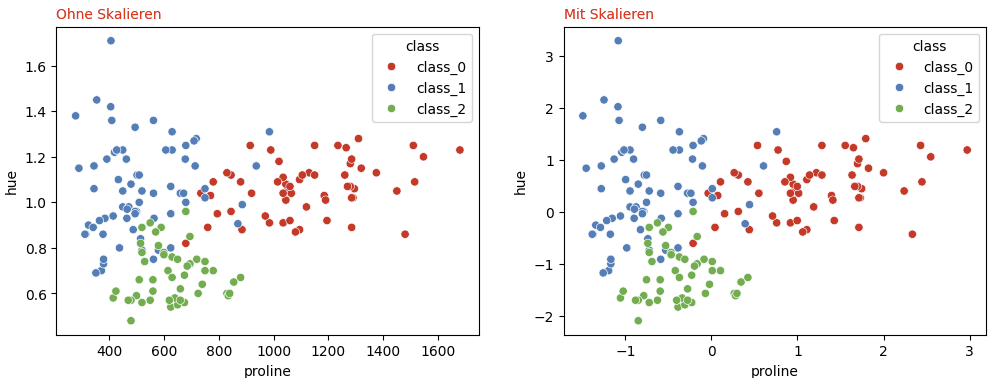

In den beiden Scatterplots wird der Einfluss des Skalierens von Daten auf ihre Darstellung veranschaulicht. Die Verteilung an sich bleibt gleich, es ändert sich nur der Wertebereich der Merkmale.

- ``Ohne Skalieren``:<br> 
Der linke Scatterplot zeigt die Originaldaten. Hier sehen wir, dass die Werte für ``"proline" deutlich höher sind (zwischen etwa 400 und 1600) als die Werte für "hue"``, die zwischen etwa 0,6 und 1,6 liegen.<br>
Die unterschiedlichen Skalen der beiden Merkmale können dazu führen, dass Merkmale mit größeren numerischen Bereichen einen unverhältnismäßig großen Einfluss auf die Analyse haben.

- ``Mit Skalieren``:<br> 
Der rechte Scatterplot zeigt die Daten nach der Skalierung. Die Achsenwerte für "proline" und "hue" liegen jetzt in einem ähnlichen Bereich, typischerweise zwischen -2 und 3. 
Die Skalierung der Daten sorgt dafür, dass kein Merkmal aufgrund seiner ursprünglichen Größenordnung dominierend ist, was besonders wichtig für Modelle ist, die auf Distanzmessungen basieren (zB: Classification und Clustering).

> ---
> #### Die Skalierung der Daten kann zu einer gerechteren und effektiveren Analyse führen.
>---

---
# ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet. 

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

### Untersuchen der Kategorie
Da die vorherzusagende Variable **``kategorisch``** ist, muß geprüft werden, ob genügend Beobachtungen in jeder Kategorie vorhanden sind. Ermittle deshalb die Anzahl der Beobachtungen in jeder Kategorie des Features, welches vorhergesagt werden soll.


In [ ]:
print(dfWine['class'].value_counts())


---
# ``Versuch 1:`` Modell OHNE Skalieren

---



### Daten auswählen



In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
# Features auswählen
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
train_x, test_x, train_y, test_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = train_x.values       # independent
train_y = train_y.values       # dependent

test_x  = test_x.values        # independent
test_y  = test_y.values        # dependent
#------------------------------------------------------------

---
## Modell erstellen und trainieren



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
model = KNeighborsClassifier(n_neighbors = 4)
model.fit(train_x, train_y)

#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)


## Modell evaluieren

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import metrics

#------------------------------------------------------------
# Prüfen der Genauigkeit des Models
print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

#------------------------------------------------------------
# Entscheidungsgrenzen auf Grund der k-Nachbarn
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=10)

DecisionBoundaryDisplay.from_estimator(
            model, train_x, alpha=0.5, eps=0.5, ax=axs[0], cmap = mpl.cm.plasma)

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=10)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, alpha=0.5, eps=0.5, ax=axs[1], cmap = mpl.cm.plasma)

# Tatsächliche Werte anzeigen
sns.scatterplot(x=dfLearn_X['proline'], y=dfLearn_X['hue'], hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[0])
sns.scatterplot(x=dfLearn_X['proline'], y=dfLearn_X['hue'], hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[1])

plt.show()

---
# ``Versuch 2:`` Modell MIT Skalieren

---



### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
# Features auswählen
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### ``FEATURES SKALIEREN`` - Dieser Schritt kommt nun hinzu

In [ ]:
from sklearn.preprocessing import StandardScaler

#------------------------------------------------------------
# Scaler erstellen und anpassen
scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(dfLearn_X)

#------------------------------------------------------------
dfLearn_X_scaled = scaler.transform(dfLearn_X)

### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
train_x_scaled, test_x_scaled, train_ys, test_ys = train_test_split( dfLearn_X_scaled, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x_scaled = train_x_scaled.values       # independent
train_y        = train_ys.values       # dependent

test_x_scaled  = test_x_scaled.values        # independent
test_y         = test_ys.values        # dependent
#------------------------------------------------------------

---
## Modell erstellen und trainieren



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
model_scaled = KNeighborsClassifier(n_neighbors = 4)
model_scaled.fit(train_x_scaled, train_y)

#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_ys = model_scaled.predict(train_x_scaled)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_ys = model_scaled.predict(test_x_scaled)


## Modell evaluieren

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import metrics

#------------------------------------------------------------
# Prüfen der Genauigkeit des Models
print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_ys))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_ys))

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

#------------------------------------------------------------
# Entscheidungsgrenzen auf Grund der k-Nachbarn
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=10)

DecisionBoundaryDisplay.from_estimator(
            model_scaled, train_x_scaled, alpha=0.5, eps=0.5, ax=axs[0], cmap = mpl.cm.plasma)

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=10)
DecisionBoundaryDisplay.from_estimator(
            model_scaled, test_x_scaled, alpha=0.5, eps=0.5, ax=axs[1], cmap = mpl.cm.plasma)

# Tatsächliche Werte anzeigen
sns.scatterplot(x=dfLearn_X_scaled['proline'], y=dfLearn_X_scaled['hue'], hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[0])
sns.scatterplot(x=dfLearn_X_scaled['proline'], y=dfLearn_X_scaled['hue'], hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[1])

plt.show()

---
# ``Zusammenfassung`` der Unterschiede


Gegenüberstellung der Daten und der Vorhersagen MIT und OHNE skalieren der Daten.

---



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

#------------------------------------------------------------
# Verteilung
axs[0].set_title('Daten OHNE Skalieren', loc='left',color='r', fontsize=10)
sns.scatterplot(x=dfLearn_X.proline, y=dfLearn_X.hue, hue=dfLearn_Y,  palette='Set1', ax=axs[0])

axs[1].set_title('Daten MIT Skalieren', loc='left',color='r', fontsize=10)
p=sns.scatterplot(x=dfLearn_X_scaled.proline, y=dfLearn_X_scaled.hue, hue=dfLearn_Y,  palette='Set1', ax=axs[1])

plt.show()


<div style="background-color:rgba(250, 0, 0, 0.1)">

---
**Fasse hier noch einmal die Vorgangsweise des Skalierens an Hand des Diagramms zusammen!**    

Füge hier deine Antwort ein



---
</div>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import metrics

#-------------------------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

#-------------------------------------------------------------------------------
# Grenzen OHNE skalieren ausgeben
axs[0].set_title('Model OHNE Skalieren', loc='left',color='r', fontsize=10)
DecisionBoundaryDisplay.from_estimator(
            model, train_x, alpha=0.5, eps=0.5, ax=axs[0], cmap = mpl.cm.plasma)
sns.scatterplot(x=dfLearn_X.proline, y=dfLearn_X.hue, hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[0])

#-------------------------------------------------------------------------------
# Grenzen MIT skalieren ausgeben
axs[1].set_title('Model MIT Skalieren', loc='left',color='r', fontsize=10)
DecisionBoundaryDisplay.from_estimator(
            model_scaled, train_x_scaled, alpha=0.5, eps=0.5, ax=axs[1], cmap = mpl.cm.plasma)
sns.scatterplot(x=dfLearn_X_scaled.proline, y=dfLearn_X_scaled.hue, hue=dfLearn_Y, palette= ['b','r','y'],  ax=axs[1])

plt.show()

<div style="background-color:rgba(250, 0, 0, 0.1)">

---
**Fasse hier noch einmal die Vorteile des Skalierens an Hand des Diagramms zusammen!**    

Füge hier deine Antwort ein



---
</div>